$Step-1$:

**Import packages**

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers,models
import matplotlib.pyplot as plt
# a  # Remove or comment out this line since 'a' is not defined

- In ANN we used fashion MNIST data set

- In CNN will use Cifar10 dataset

$Step-2$:

**About the dataset**

Here we use a dataset name : CIFAR

It containes 60000 images and 10 classes

Each class containes 6000 images

Data set is divided into two parts training images: 50,000

testing images: 10,000

In [ ]:
dir(datasets)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'boston_housing',
 'california_housing',
 'cifar10',
 'cifar100',
 'fashion_mnist',
 'imdb',
 'mnist',
 'reuters']

In [ ]:
#datasets.fashion_mnist.load_data()

In [ ]:
# (X_train,y_train),(X_test,y_test)=datasets.fashion_mnist.load_data()
# X_train.shape   # 60000,28,28

In [ ]:
# datasets.cifar10.load_data()


In [ ]:
(X_train,y_train),(X_test,y_test)=datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


(50000, 32, 32, 3)

In [ ]:
(train_images,train_labels),(test_images,test_labels)=datasets.cifar10.load_data()

- Data dimensions 3 means : (n,w,h)

    - n= no of images

    - h = height of the image

    - w = width of the image

- Data dimensions 4 means : (n,w,h,c)

    - n= no of images

    - h = height of the image

    - w = width of the image

    - c = no of channels

- in mnist data the lables are in single list

- but in cifar data the lables are presented as list in list

- Mnist data image shape : 28*28

- Cifar data image shape : 32*32

In [ ]:
train_images.shape

# 50000 images
# 32 is width
# 32 is height
# 3 RGB : these are colour images

(50000, 32, 32, 3)

In [ ]:
# in each image how many pixle value
32*32*3

3072

In [ ]:
# First image
train_images[0].shape

(32, 32, 3)

In [ ]:
import numpy as np
tarun=[[1,2,3],[1,2,3]]
np.array([[[1,2,3],[1,2,3]],
          [[1,2,3],[1,2,3]],
          [[1,2,3],[1,2,3]]]).shape

(3, 2, 3)

In [ ]:
len(train_images[0][0][0])

3

In [ ]:
# train_images[0][0]  # clear
# train_images[0][1]
# train_images[0][2]

$Step-3$:

**Draw the images**

In [ ]:
# Take the class labels first
train_labels   # list in list

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
len(train_labels)

50000

In [ ]:
datasets.cifar10.load_data

<function keras.src.datasets.cifar10.load_data()>

In [ ]:
class_names=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
len(class_names)

# this will not available
# this lables are im providing for easy analysis

10

In [ ]:
train_labels[0][0]  # 6
train_labels[1][0] # 9

#train_labels[i][0]

np.uint8(9)

In [ ]:
train_labels[0][0],train_labels[1][0],train_labels[2][0]

# train_labels[i][0]

(6, 9, 9)

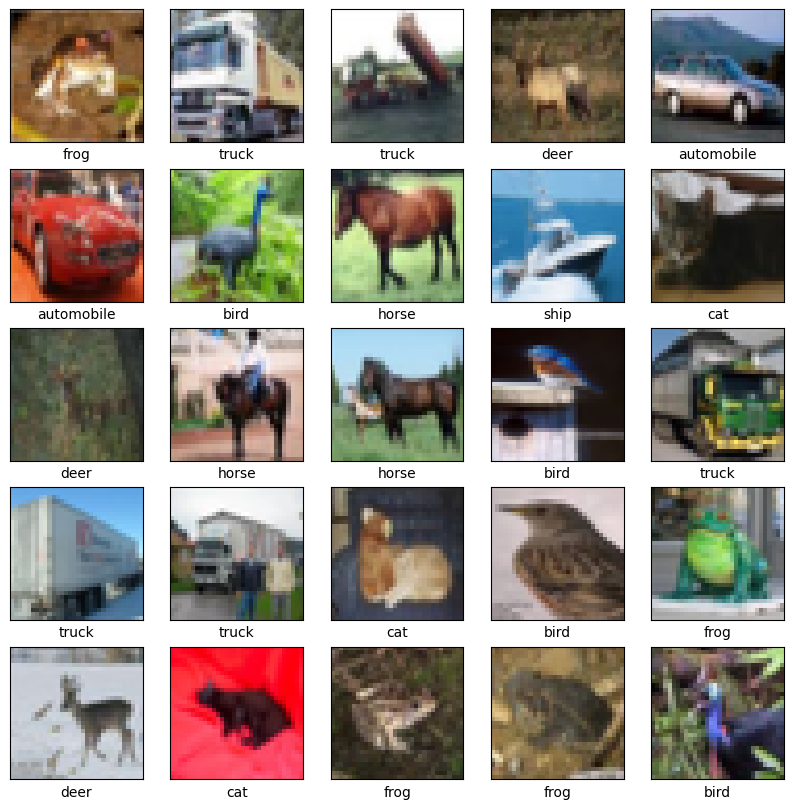

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    #plt.xlabel(train_labels[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [ ]:
# Try to apply some smoothing tech
# Guassian blurr
# Median filter
# Those are avaialble in opnecv

$Step-4$

**Create the CNN network**

- Convolution

- Activation

- Striding (default =1) (not necessary to provide

- Padding (not necessary to provide)

- pooling

**Conv2D**: Images  Height,width,channel

**Conv3d**: Videos frames,Height,width,channel

In [ ]:
from tensorflow.keras import datasets, layers,models
model=models.Sequential()

#############################################################################################
model.add(layers.Conv2D(32, # filters
                        (3,3), # filter size/kernal size
                        activation='relu',
                        input_shape=(32,32,3)
                        ))  # Stride / padding : default

model.add(layers.MaxPool2D((2,2)))  # shape of the pool

###############################################################################################
model.add(layers.Conv2D(64, # filters
                        (3,3), # filter size/kernal size
                        activation='relu'))  # stride /padding: deafault

model.add(layers.MaxPool2D((2,2)))

###############################################################################################

model.add(layers.Conv2D(64, # filters
                        (3,3), # filter size/kernal size
                        activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

$Step-5$:

**Add dense layers**

In [ ]:
model.add(layers.Flatten()) # After convolution ==== Fully connect layer
# no need of input shape here
model.add(layers.Dense(64,activation='relu'))  # Hidden layer 64 neurons, relu activation function
#model.add(layers.Dense(10)) # 10 classes so 10 neurons
model.add(layers.Dense(10,activation='softmax')) # softmax activation function

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

$Step-6$:

**Compile the model and fit**

In [ ]:
model.compile(optimizer='adam', #optimizer
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), #loss
              metrics=['accuracy']# metric
              )

history=model.fit(train_images,
                  train_labels,
                  epochs=20,
                  #validation_data=(test_images,test_labels),
                  validation_split=0.2)

# 1 epoch= one forward pass + one backward pass
# Total train images are 50000
# By default batch size =32
# 50000/32~=1563 batches

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.2716 - loss: 2.6777 - val_accuracy: 0.4556 - val_loss: 1.4991
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4809 - loss: 1.4242 - val_accuracy: 0.5102 - val_loss: 1.3724
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5453 - loss: 1.2737 - val_accuracy: 0.5514 - val_loss: 1.2876
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5888 - loss: 1.1616 - val_accuracy: 0.5995 - val_loss: 1.1509
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6203 - loss: 1.0769 - val_accuracy: 0.6034 - val_loss: 1.1399
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6541 - loss: 0.9967 - val_accuracy: 0.6258 - val_loss: 1.0880
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6810 - loss: 0.9155 - val_accuracy: 0.6314 - val_loss: 1.1048
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7015 - loss: 0.8637 - val_accu

In [ ]:
history.history

{'accuracy': [0.36037498712539673,
  0.49470001459121704,
  0.5476750135421753,
  0.589775025844574,
  0.6196749806404114,
  0.6559000015258789,
  0.6757749915122986,
  0.6956750154495239,
  0.7151250243186951,
  0.7335749864578247,
  0.7482500076293945,
  0.7602999806404114,
  0.7765750288963318,
  0.7860249876976013,
  0.7939500212669373,
  0.8084499835968018,
  0.8131250143051147,
  0.8209750056266785,
  0.826200008392334,
  0.833899974822998],
 'loss': [1.8429523706436157,
  1.3957487344741821,
  1.2674589157104492,
  1.1615958213806152,
  1.0830713510513306,
  0.9966810345649719,
  0.9268752932548523,
  0.8741938471794128,
  0.8177977204322815,
  0.7649192214012146,
  0.7248169183731079,
  0.684642493724823,
  0.6418042778968811,
  0.6187542080879211,
  0.5925537347793579,
  0.555779218673706,
  0.5379632711410522,
  0.5142054557800293,
  0.4963081479072571,
  0.47702789306640625],
 'val_accuracy': [0.45559999346733093,
  0.510200023651123,
  0.5514000058174133,
  0.59950000047683

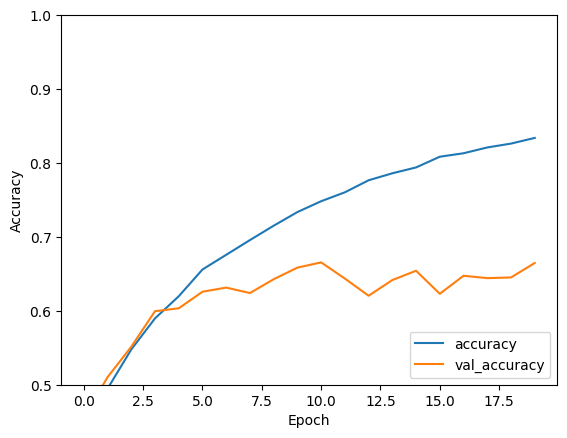

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.6656 - loss: 1.3374


In [ ]:
model.weights

In [ ]:
test_labels.flatten()

**Prediction**

In [ ]:
test_images.shape  # (n,h,w,c)

(10000, 32, 32, 3)

In [ ]:
test_images[0].shape # (1,h,w,c)
# (1,32,32,3)

(32, 32, 3)

In [ ]:
np.expand_dims(test_images[0], axis=0).shape

(1, 32, 32, 3)

In [ ]:
import numpy as np
import pandas as pd

# Convert the single image to a batch of size 1
y_pred = model.predict(np.expand_dims(test_images[0], axis=0))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step


array([[3.4045018e-04, 1.1111046e-03, 3.9531119e-04, 8.9444816e-01,
        1.6397589e-05, 3.9817847e-02, 4.1959438e-02, 1.3219620e-05,
        2.1443563e-02, 4.5442753e-04]], dtype=float32)

In [ ]:
np.max(y_pred), np.argmax(y_pred)

(0.89444816, 3)

In [ ]:
test_labels[0]

array([3], dtype=uint8)

In [ ]:
import numpy as np
import pandas as pd

y_pred = model.predict(test_images)      # 10k images === 10k predictions
max_prob=[np.max(i)  for i in y_pred]    # Each prediction max prob saving in a list
index=[np.argmax(i) for i in y_pred]     # Each prediction max prob index saving in a list
prediction_class=[class_names[i] for i in index] # Class name
Ground_Truth_class=[class_names[i] for i in test_labels.flatten()]
# test labels are in a list in list , so we are applying flatten method

d1=pd.DataFrame(zip(max_prob,index,prediction_class,Ground_Truth_class),
             columns=['Max_proba','Index','Prediction_class','Ground_Truth_class'])
con=d1['Prediction_class']==d1['Ground_Truth_class']
d1['output']=np.where(con,1,0)
accuracy=d1['output'].sum()/len(d1['output'])
accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


0.6542

In [ ]:
d1

,Max_proba,Index,Prediction_class,Ground_Truth_class,output
0,0.894448,3,cat,cat,1
1,0.847079,8,ship,ship,1
2,0.471011,9,truck,ship,0
3,0.881933,0,airplane,airplane,1
4,0.863288,6,frog,frog,1
...,...,...,...,...,...
9995,0.882133,3,cat,ship,0
9996,0.746727,3,cat,cat,1
9997,0.614298,5,dog,dog,1
9998,0.634697,4,deer,automobile,0


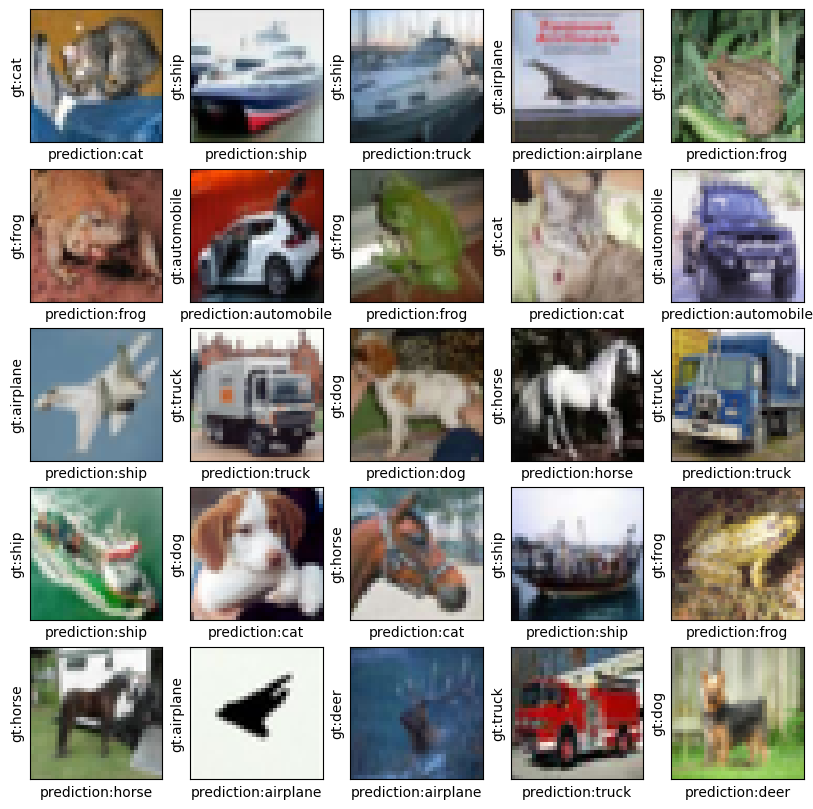

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i])
    plt.xlabel(f'prediction:{class_names[np.argmax(y_pred[i])]}')
    plt.ylabel(f'gt:{class_names[test_labels.flatten()[i]]}')
plt.show()